In [1]:
import numpy as np
import pandas as pd

In [2]:
df_cum = pd.read_excel(r'C:\Users\86182\Desktop\cumcm2018c1.xlsx')
df_cum

,会员卡号,出生日期,性别,登记时间
0,c68b20b4,2002-11-02 00:00:00,0.0,2013-05-11 00:00:00.000
1,1ca15332,NaN,0.0,2004-11-04 16:31:52.436
2,a37cc182,1967-02-17 00:00:00,0.0,2004-12-31 21:24:34.216
3,2ab88539,1982-06-01 00:00:00,0.0,2010-11-19 00:00:00.000
4,b4c77269,1964-02-05 00:00:00,0.0,2007-12-14 00:00:00.000
...,...,...,...,...
194755,a97474e0,NaN,NaN,NaT
194756,4e14ad22,NaN,0.0,2013-08-30 00:00:00.000
194757,f20299a8,NaN,NaN,2014-03-18 00:00:00.000
194758,a3a27f12,1973-01-10 00:00:00,0.0,2015-03-10 00:00:00.000


In [3]:
df_sale = pd.read_csv(r'C:\Users\86182\Desktop\cumcm2018c2.csv')
df_sale

E:\Anaconda\lib\site-packages\IPython\core\interactiveshell.py:2785: DtypeWarning: Columns (0,11) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


,会员卡号,消费产生的时间,商品编码,销售数量,商品售价,消费金额,商品名称,此次消费的会员积分,收银机号,单据号,柜组编码,柜组名称
0,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,290.0,270.20,兰芝化妆品正价瓶,270.20,6,25bb,8077.0,兰芝柜
1,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,325.0,302.80,兰芝化妆品正价瓶,302.80,6,25bb,8077.0,兰芝柜
2,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,195.0,181.80,兰芝化妆品正价瓶,181.80,6,25bb,8077.0,兰芝柜
3,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,270.0,251.55,兰芝化妆品正价瓶,251.55,6,25bb,8077.0,兰芝柜
4,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,2,245.0,456.55,兰芝化妆品正价瓶,456.55,6,25bb,8077.0,兰芝柜
...,...,...,...,...,...,...,...,...,...,...,...,...
1893527,607c7cde,2018-01-03 21:38:15.343,c483e08b,1,200.0,200.00,植村秀眉笔4g,200.00,91,3d84,8156.0,Shu Uemura
1893528,220c0564,2018-01-03 21:41:53.140,cd93b1ca,1,1.0,1.00,爱慕内衣正价件,1.00,264,7cd8,4332.0,Aimer
1893529,220c0564,2018-01-03 21:41:53.140,cd93b1ca,1,490.0,490.00,爱慕内衣正价件,490.00,264,7cd8,4332.0,Aimer
1893530,220c0564,2018-01-03 21:41:53.140,cd93b1ca,1,280.0,280.00,爱慕内衣正价件,280.00,264,7cd8,4332.0,Aimer


In [4]:
# 查看数据基本信息
print("会员信息表原始记录数：", df_cum.shape[0])
print("字段数：", df_cum.shape[1])
print("\n缺失值比例：")
display(df_cum.isnull().mean().round(4))  # 显示各字段缺失比例

# 按会员卡号去重（保留第一条记录）
df_cum = df_cum.drop_duplicates(subset='会员卡号', keep='first')
print("\n去重后会员数：", len(df_cum['会员卡号'].unique()))

会员信息表原始记录数： 194760
字段数： 4

缺失值比例：


会员卡号    0.0000
出生日期    0.1755
性别      0.0484
登记时间    0.0651
dtype: float64


去重后会员数： 194754


In [5]:
# 移除登记时间缺失的记录（保留后续建模所需数据）
df_cum = df_cum.dropna(subset=['登记时间'], how='any')
print("移除登记时间缺失后记录数：", df_cum.shape[0])

# 填充性别缺失值（使用众数填充）
gender_mode = df_cum['性别'].mode().values[0]
df_cum['性别'] = df_cum['性别'].fillna(gender_mode)
print(f"性别缺失值填充完成（众数：{gender_mode}）")

移除登记时间缺失后记录数： 182070
性别缺失值填充完成（众数：0.0）


In [6]:
# 提取有效出生日期记录并计算年龄（基于年份）
df_age = df_cum[df_cum['出生日期'].notna()].copy()
df_age['出生日期'] = pd.to_datetime(df_age['出生日期'], errors='coerce')  # 转换为日期类型
df_age['出生年份'] = df_age['出生日期'].dt.year  # 提取出生年份

# 过滤合理年龄范围（1920-2020年）
df_age = df_age[(df_age['出生年份'] >= 1920) & (df_age['出生年份'] <= 2020)]
print(f"有效出生年份记录数：{df_age.shape[0]}")
display(df_age['出生年份'].value_counts())

有效出生年份记录数：137660


1987.0    5175
1982.0    5152
1986.0    5102
1975.0    4697
1988.0    4673
          ... 
1927.0       2
1924.0       2
2018.0       2
1931.0       1
1921.0       1
Name: 出生年份, Length: 97, dtype: int64

In [7]:
# 保留核心字段并重置索引
df_cum = df_cum[['会员卡号', '性别', '登记时间']].reset_index(drop=True)
print("会员信息表清洗完成，最终结构：")
print("记录数：", df_cum.shape[0])
print("字段：", df_cum.columns.tolist())
df_cum.head()

会员信息表清洗完成，最终结构：
记录数： 182070
字段： ['会员卡号', '性别', '登记时间']


,会员卡号,性别,登记时间
0,c68b20b4,0.0,2013-05-11 00:00:00.000
1,1ca15332,0.0,2004-11-04 16:31:52.436
2,a37cc182,0.0,2004-12-31 21:24:34.216
3,2ab88539,0.0,2010-11-19 00:00:00.000
4,b4c77269,0.0,2007-12-14 00:00:00.000


In [8]:
# 查看关键字段缺失值
print("销售流水表原始记录数：", df_sale.shape[0])
print("\n会员卡号/消费金额/销售数量缺失比例：")
display(df_sale[['会员卡号', '消费金额', '销售数量']].isnull().mean().round(4))

# 移除会员卡号缺失的记录（无法关联会员信息）
df_sale_clean = df_sale.dropna(subset=['会员卡号'], how='any')
print("\n移除会员卡号缺失后记录数：", df_sale_clean.shape[0])

销售流水表原始记录数： 1893532

会员卡号/消费金额/销售数量缺失比例：


会员卡号    0.5373
消费金额    0.0000
销售数量    0.0000
dtype: float64


移除会员卡号缺失后记录数： 876046


In [9]:
# 筛选消费金额、销售数量、会员积分均大于0且无缺失的记录

#  先将积分字段转换为数值型（处理非数值数据）
df_sale_clean['此次消费的会员积分'] = pd.to_numeric(
    df_sale_clean['此次消费的会员积分'], 
    errors='coerce'  # 无法转换的值转为NaN
)
df_sale_clean['此次消费的会员积分']

E:\Anaconda\lib\site-packages\ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


0          270.20
1          302.80
2          181.80
3          251.55
4          456.55
            ...  
1893527    200.00
1893528      1.00
1893529    490.00
1893530    280.00
1893531    880.00
Name: 此次消费的会员积分, Length: 876046, dtype: float64

In [10]:
#  检查各字段数据类型（确保为数值型）
print("字段数据类型：")
display(df_sale_clean[['销售数量', '消费金额', '此次消费的会员积分']].dtypes)

字段数据类型：


销售数量           int64
消费金额         float64
此次消费的会员积分    float64
dtype: object

In [11]:
#  创建过滤条件（包含缺失值检查）
mask = (
    df_sale_clean['销售数量'].gt(0) &        # 销售数量>0
    df_sale_clean['消费金额'].gt(0) &        # 消费金额>0
    df_sale_clean['此次消费的会员积分'].notna() &  # 积分非空
    df_sale_clean['此次消费的会员积分'].gt(0)  # 积分>0
)

#  应用过滤条件并重置索引
df_sale_clean = df_sale_clean[mask].reset_index(drop=True)
print(f"有效交易记录数：{df_sale_clean.shape[0]}")

有效交易记录数：738462


In [12]:
# 保留核心字段（移除无关列）
keep_columns = [
    '会员卡号', '消费产生的时间', '商品编码', 
    '销售数量', '商品售价', '消费金额', 
    '商品名称', '此次消费的会员积分', '单据号'
]
df_sale_clean = df_sale_clean[keep_columns].copy()
print("保留字段后结构：")
print("记录数：", df_sale_clean.shape[0])
print("字段：", df_sale_clean.columns.tolist())
df_sale_clean.head()

保留字段后结构：
记录数： 738462
字段： ['会员卡号', '消费产生的时间', '商品编码', '销售数量', '商品售价', '消费金额', '商品名称', '此次消费的会员积分', '单据号']


,会员卡号,消费产生的时间,商品编码,销售数量,商品售价,消费金额,商品名称,此次消费的会员积分,单据号
0,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,290.0,270.20,兰芝化妆品正价瓶,270.20,25bb
1,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,325.0,302.80,兰芝化妆品正价瓶,302.80,25bb
2,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,195.0,181.80,兰芝化妆品正价瓶,181.80,25bb
3,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,270.0,251.55,兰芝化妆品正价瓶,251.55,25bb
4,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,2,245.0,456.55,兰芝化妆品正价瓶,456.55,25bb


In [13]:
# 左连接：以销售记录为主，关联会员信息
df_merged = pd.merge(
    df_sale_clean,        # 左表：销售记录
    df_cum,               # 右表：会员信息
    on='会员卡号',         # 关联字段
    how='left'            # 保留所有销售记录
)
print("合并后数据集形状：", df_merged.shape)
df_merged.head()

合并后数据集形状： (738462, 11)


,会员卡号,消费产生的时间,商品编码,销售数量,商品售价,消费金额,商品名称,此次消费的会员积分,单据号,性别,登记时间
0,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,290.0,270.20,兰芝化妆品正价瓶,270.20,25bb,NaN,NaT
1,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,325.0,302.80,兰芝化妆品正价瓶,302.80,25bb,NaN,NaT
2,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,195.0,181.80,兰芝化妆品正价瓶,181.80,25bb,NaN,NaT
3,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,270.0,251.55,兰芝化妆品正价瓶,251.55,25bb,NaN,NaT
4,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,2,245.0,456.55,兰芝化妆品正价瓶,456.55,25bb,NaN,NaT


In [14]:
# 标记是否为有效会员（确保为整数类型）
df_merged['是否会员'] = np.where(df_merged['性别'].notna(), 1, 0).astype('int64')
print("'是否会员'字段数据类型：", df_merged['是否会员'].dtype)

# 计算会员占比（使用内置round函数避免属性冲突）
member_ratio = df_merged['是否会员'].mean()
if pd.notna(member_ratio):
    # 使用内置round函数，格式化为4位小数
    formatted_ratio = round(member_ratio, 4)
    print(f"会员占比：{formatted_ratio}")
else:
    print("会员占比计算失败，可能因数据全为空")

'是否会员'字段数据类型： int64
会员占比：0.5328


In [15]:
# 查看合并后数据缺失情况
print("合并后数据缺失值比例：")
display(df_merged.isnull().mean().round(4))

# 统计有效会员交易记录
member_transactions = df_merged[df_merged['是否会员'] == 1]
print(f"\n有效会员交易记录数：{len(member_transactions)}")

合并后数据缺失值比例：


会员卡号         0.0000
消费产生的时间      0.0000
商品编码         0.0000
销售数量         0.0000
商品售价         0.0000
消费金额         0.0000
商品名称         0.0000
此次消费的会员积分    0.0000
单据号          0.0000
性别           0.4672
登记时间         0.4672
是否会员         0.0000
dtype: float64


有效会员交易记录数：393482


In [16]:
!pip install pyecharts

In [17]:
import matplotlib.pyplot as plt
from pyecharts import options as opts
from pyecharts.charts import Pie
import seaborn as sns
from pyecharts.charts import Bar
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 

In [18]:
gender_counts = df_cum['性别'].value_counts(normalize=True).mul(100).round(2)
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 

# 创建性别名称映射
gender_map = {0: "女生", 1: "男生"}
gender_counts.index = gender_counts.index.map(gender_map)

c = (
    Pie()
    .add(
        "",
        [list(z) for z in zip(gender_counts.index.astype(str), gender_counts.values)],
        radius=["30%", "55%"],
        label_opts=opts.LabelOpts(
            formatter="{b}: {c}%",
            font_size=10,  # 标签字体大小
            font_family="SimHei"  # 显式指定黑体
        )
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="会员性别比例分布",
            title_textstyle_opts=opts.TextStyleOpts(
                font_size=14,  # 标题字体大小
                font_family="SimHei"  # 显式指定黑体
            )
        ),
        legend_opts=opts.LegendOpts(
            textstyle_opts=opts.TextStyleOpts(
                font_size=12,  # 图例字体大小
                font_family="SimHei"  # 显式指定黑体
            )
        )
    )
)

c.render_notebook()

E:\Anaconda\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


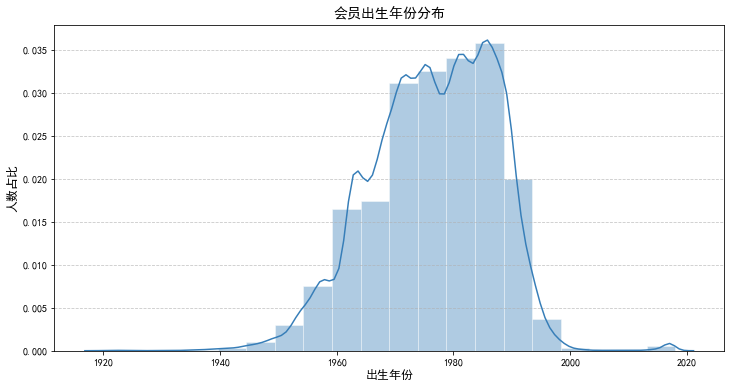

In [19]:
plt.figure(figsize=(12, 6))
sns.distplot(df_age['出生年份'], bins=20, kde=True, color='#377eb8', hist_kws={'edgecolor':'white'})
plt.title('会员出生年份分布', fontsize=14)
plt.xlabel('出生年份', fontsize=12)
plt.ylabel('人数占比', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [20]:
# 定义年龄段映射函数
def map_to_age_group(birth_year):
    if 1920 <= birth_year <= 1950:
        return '老年'
    elif 1960 <= birth_year <= 1990:
        return '中年'
    elif 1990 <= birth_year <= 2020:
        return '青年'
    else:
        return None  # 忽略其他年龄段

# 应用映射函数并过滤掉无效值
df_age['年龄段'] = df_age['出生年份'].apply(map_to_age_group)
df_age = df_age.dropna(subset=['年龄段'])  # 移除不在三个主要年龄段的数据
df_age

,会员卡号,出生日期,性别,登记时间,出生年份,年龄段
0,c68b20b4,2002-11-02,0.0,2013-05-11 00:00:00.000,2002.0,青年
2,a37cc182,1967-02-17,0.0,2004-12-31 21:24:34.216,1967.0,中年
3,2ab88539,1982-06-01,0.0,2010-11-19 00:00:00.000,1982.0,中年
4,b4c77269,1964-02-05,0.0,2007-12-14 00:00:00.000,1964.0,中年
5,83a91070,1968-06-18,1.0,2004-05-01 16:50:13.950,1968.0,中年
...,...,...,...,...,...,...
194749,9e7c711e,1993-06-24,1.0,2013-08-30 00:00:00.000,1993.0,青年
194751,5b7c99c6,1979-04-23,1.0,2010-06-14 00:00:00.000,1979.0,中年
194752,3f98ac2e,1981-03-02,1.0,2013-08-30 00:00:00.000,1981.0,中年
194758,a3a27f12,1973-01-10,0.0,2015-03-10 00:00:00.000,1973.0,中年


In [21]:
# 统计各年龄段的人数
age_group_counts = df_age['年龄段'].value_counts().reset_index()
age_group_counts.columns = ['年龄段', '人数']
age_group_counts

,年龄段,人数
0,中年,120606
1,青年,8941
2,老年,1270


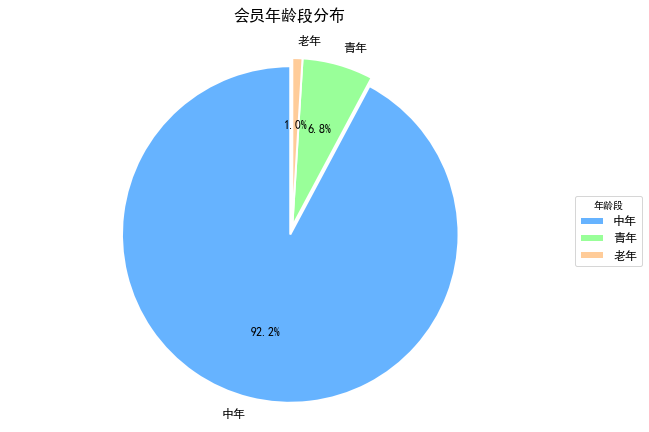

In [22]:
# 定义美观的三色配色方案（蓝绿橙）
colors = ['#66b3ff',  # 蓝色 - 老年
          '#99ff99',  # 绿色 - 中年
          '#ffcc99']  # 橙色 - 青年

# 创建画布和子图
fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')

# 绘制饼图
wedges, texts, autotexts = ax.pie(
    age_group_counts['人数'],
    labels=age_group_counts['年龄段'],
    colors=colors,
    autopct='%1.1f%%',
    explode=[0.05, 0, 0],  # 突出显示老年组
    startangle=90,
    shadow=False,
    wedgeprops={'edgecolor': 'w', 'linewidth': 2},
    textprops={'fontsize': 12}
)

# 设置百分比文本颜色为黑色
for text in autotexts:
    text.set_color('black')

# 添加标题和图例
plt.title('会员年龄段分布', fontsize=16, pad=20)
plt.legend(
    wedges, 
    age_group_counts['年龄段'],
    title="年龄段",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=12
)

# 设置饼图为正圆形
plt.axis('equal')

plt.show()    

In [23]:
# 标记消费表中的会员（卡号存在于会员表中）
df_sale_clean['是否会员'] = df_sale_clean['会员卡号'].isin(df_cum['会员卡号']).astype(int)
member_sales = df_sale_clean[df_sale_clean['是否会员'] == 1]  # 会员消费数据
member_sales

,会员卡号,消费产生的时间,商品编码,销售数量,商品售价,消费金额,商品名称,此次消费的会员积分,单据号,是否会员
10,d8d36575,2015-01-01 00:06:38.313,d313ab1e,1,1760.0,1760.0,MARYLINGC件,1678.82,5858,1
11,d8d36575,2015-01-01 00:06:38.313,d313ab1e,1,9072.0,9072.0,MARYLINGC件,8653.56,5858,1
12,d8d36575,2015-01-01 00:06:38.313,50a2c4f5,1,1507.0,1507.0,汤普葛罗女鞋活动促销双,1437.49,5858,1
13,d8d36575,2015-01-01 00:06:38.313,50a2c4f5,1,899.0,899.0,汤普葛罗女鞋活动促销双,857.54,5858,1
14,d8d36575,2015-01-01 00:06:38.313,d313ab1e,1,1960.0,1960.0,MARYLINGC件,1869.59,5858,1
...,...,...,...,...,...,...,...,...,...,...
738453,826ea280,2018-01-03 21:25:16.236,2c276195,1,299.0,299.0,芭芭麻麻正价件,299.00,fcd0,1
738454,826ea280,2018-01-03 21:25:16.236,2c276195,1,399.0,399.0,芭芭麻麻正价件,399.00,fcd0,1
738455,5d761c48,2018-01-03 21:27:28.686,a1e1cc27,1,990.0,990.0,Gucci品牌 正价无,990.00,1f26,1
738456,607c7cde,2018-01-03 21:38:15.343,3bc576f1,2,480.0,960.0,植村秀腮红刷20,960.00,3d84,1


In [24]:
non_member_sales = df_sale_clean[df_sale_clean['是否会员'] == 0]  # 非会员消费数据
non_member_sales

,会员卡号,消费产生的时间,商品编码,销售数量,商品售价,消费金额,商品名称,此次消费的会员积分,单据号,是否会员
0,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,290.0,270.20,兰芝化妆品正价瓶,270.20,25bb,0
1,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,325.0,302.80,兰芝化妆品正价瓶,302.80,25bb,0
2,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,195.0,181.80,兰芝化妆品正价瓶,181.80,25bb,0
3,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,1,270.0,251.55,兰芝化妆品正价瓶,251.55,25bb,0
4,1be1e3fe,2015-01-01 00:05:41.593,f09c9303,2,245.0,456.55,兰芝化妆品正价瓶,456.55,25bb,0
...,...,...,...,...,...,...,...,...,...,...
738451,08620f11,2018-01-03 21:18:55.686,12c40a6a,1,270.0,70.00,兰蔻唇膏/玫瑰唇釉.,70.00,233b,0
738458,220c0564,2018-01-03 21:41:53.140,cd93b1ca,1,1.0,1.00,爱慕内衣正价件,1.00,7cd8,0
738459,220c0564,2018-01-03 21:41:53.140,cd93b1ca,1,490.0,490.00,爱慕内衣正价件,490.00,7cd8,0
738460,220c0564,2018-01-03 21:41:53.140,cd93b1ca,1,280.0,280.00,爱慕内衣正价件,280.00,7cd8,0


In [25]:
# 统计订单数（去重单据号）
order_data = {
    '用户类型': ['会员', '非会员'],
    '订单数': [
        len(member_sales['单据号'].unique()),
        len(non_member_sales['单据号'].unique())
    ]
}
order_df = pd.DataFrame(order_data)
order_df

,用户类型,订单数
0,会员,468
1,非会员,461


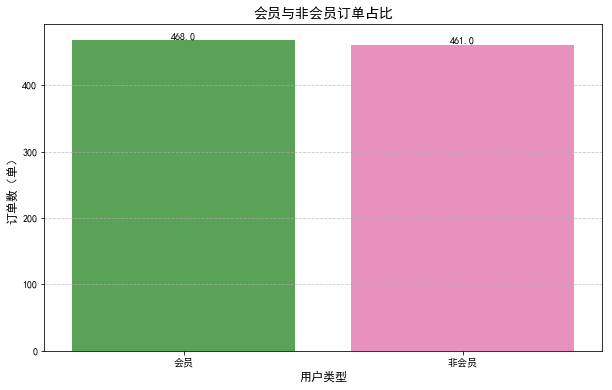

In [26]:
# Matplotlib 双柱状图
plt.figure(figsize=(10, 6))
sns.barplot(x='用户类型', y='订单数', data=order_df, palette=['#4daf4a', '#f781bf'])
plt.title('会员与非会员订单占比', fontsize=14)
plt.xlabel('用户类型', fontsize=12)
plt.ylabel('订单数（单）', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 添加数据标签（千位分隔符）
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width()/2., height,
            f'{height:,}',
            ha='center', va='bottom', fontsize=10)

plt.show()

In [27]:
# 计算金额
total_amount = df_sale_clean['消费金额'].sum()
total_amount

1037762233.8

In [28]:
member_amount = member_sales['消费金额'].sum()
member_amount

560236552.64

In [29]:
non_member_amount = non_member_sales['消费金额'].sum()
non_member_amount

477525681.1600001

In [30]:
#Pyecharts嵌套饼图
c = (
    Pie()
    .add(
        "外层",
        [("总计", total_amount)],
        radius=["60%", "75%"],
        label_opts=opts.LabelOpts(is_show=False),
    )
    .add(
        "内层",
        [("会员", member_amount), ("非会员", non_member_amount)],
        radius=["30%", "50%"],
        label_opts=opts.LabelOpts(
            formatter="{b}：{c}元\n({d}%)",  # 移除:.2f，让 Pyecharts 自动处理格式
            font_size=12,
            font_family="SimHei"  # 确保中文显示
        ),
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="消费金额占比分析",
            title_textstyle_opts=opts.TextStyleOpts(
                font_size=16,
                font_family="SimHei"
            )
        ),
        legend_opts=opts.LegendOpts(
            textstyle_opts=opts.TextStyleOpts(
                font_size=12,
                font_family="SimHei"
            ),
            pos_right="10%"
        )
    )
)
c.render_notebook()

In [31]:
# 提取季度信息并转换为字符串格式
member_sales['消费季度'] = pd.to_datetime(member_sales['消费产生的时间']).dt.to_period('Q').astype(str)

# 按季度统计消费金额
quarterly = member_sales.groupby('消费季度')['消费金额'].sum().sort_index()
print(quarterly.apply(lambda x: f"{x:,.2f} 元"))

消费季度
2015Q1    61,967,677.49 元
2015Q2    43,866,378.13 元
2015Q3    25,679,370.63 元
2015Q4        71,296.00 元
2016Q1    11,855,695.83 元
2016Q2    43,076,292.37 元
2016Q3    49,247,952.17 元
2016Q4    67,977,253.29 元
2017Q1    55,133,996.40 元
2017Q2    58,430,513.79 元
2017Q3    46,470,114.31 元
2017Q4    91,528,695.07 元
2018Q1     4,931,317.16 元
Name: 消费金额, dtype: object


E:\Anaconda\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


E:\Anaconda\lib\site-packages\matplotlib\cbook\__init__.py:2064: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
E:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:248: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]


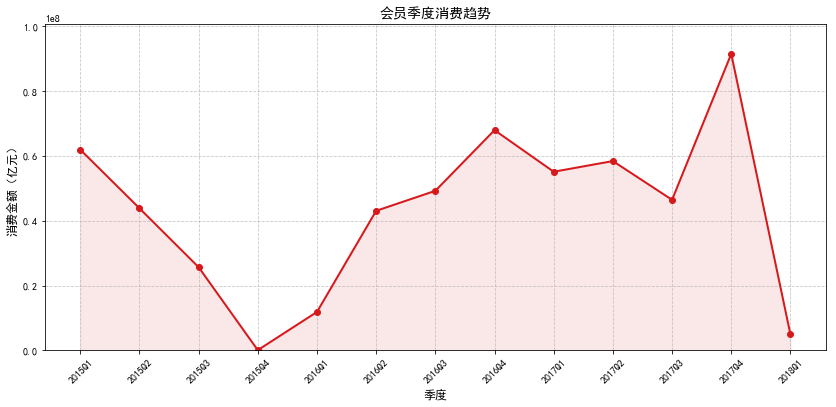

In [32]:
# 绘制折线图
plt.figure(figsize=(14, 6))
plt.plot(quarterly.index, quarterly.values, marker='o', color='#d7191c', linewidth=2)
plt.fill_between(range(len(quarterly)), quarterly.values, alpha=0.1, color='#d7191c')
plt.title('会员季度消费趋势', fontsize=14)
plt.xlabel('季度', fontsize=12)
plt.ylabel('消费金额（亿元）', fontsize=12)

# 设置X轴标签
plt.xticks(range(len(quarterly)), quarterly.index, rotation=45, fontsize=10)

# 手动设置Y轴范围（关键修改点）
min_value = 0
max_value = quarterly.values.max() * 1.1  # 留出10%的空间
plt.ylim(min_value, max_value)

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.7)

# 显示图形
plt.show()

In [33]:
# 数据处理部分保持不变
member_sales['消费星期'] = pd.to_datetime(member_sales['消费产生的时间']).dt.weekday
daily_avg = member_sales.groupby('消费星期')['消费金额'].mean().round(2)

# 修正标签格式化参数
c = (
    Bar()
    .add_xaxis(["周一", "周二", "周三", "周四", "周五", "周六", "周日"])
    .add_yaxis(
        "平均消费金额",
        daily_avg.tolist(),
        label_opts=opts.LabelOpts(
            position="right",
            formatter="{@[1]}元",  # 修正后的格式化参数
            font_size=10
        ),
    )
    .reversal_axis()
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="会员每日平均消费金额",
            title_textstyle_opts=opts.TextStyleOpts(font_size=14)
        ),
        yaxis_opts=opts.AxisOpts(
            name="星期",
            name_textstyle_opts=opts.TextStyleOpts(font_size=12)
        ),
        xaxis_opts=opts.AxisOpts(
            name="金额（元）",
            name_textstyle_opts=opts.TextStyleOpts(font_size=12)
        ),
    )
)
c.render_notebook()


E:\Anaconda\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [34]:
# 新增消费时段列（按小时划分）
member_sales['消费时间'] = pd.to_datetime(member_sales['消费产生的时间'])
member_sales['消费小时'] = member_sales['消费时间'].dt.hour

def map_to_period(hour):
    if 6 <= hour < 12:
        return '上午（6-12点）'
    elif 12 <= hour < 18:
        return '下午（12-18点）'
    elif 18 <= hour < 24:
        return '晚上（18-24点）'
    else:
        return '凌晨（0-6点）'  # 低峰期

member_sales['消费时段'] = member_sales['消费小时'].apply(map_to_period)
member_sales['消费时段'] 

E:\Anaconda\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
E:\Anaconda\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
E:\Anaconda\lib\site-packages\ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

10          凌晨（0-6点）
11          凌晨（0-6点）
12          凌晨（0-6点）
13          凌晨（0-6点）
14          凌晨（0-6点）
             ...    
738453    晚上（18-24点）
738454    晚上（18-24点）
738455    晚上（18-24点）
738456    晚上（18-24点）
738457    晚上（18-24点）
Name: 消费时段, Length: 393482, dtype: object

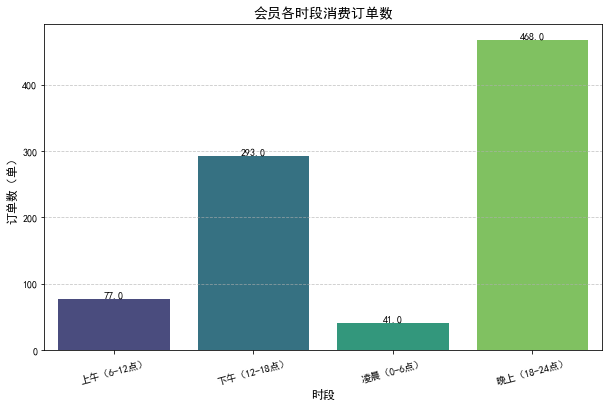

In [35]:
# 按时段统计订单数（去重单据号）
period_order = member_sales.groupby('消费时段')['单据号'].nunique().reset_index()
period_order.columns = ['消费时段', '订单数']

# 绘制柱状图
plt.figure(figsize=(10, 6))
sns.barplot(x='消费时段', y='订单数', data=period_order, palette='viridis')
plt.title('会员各时段消费订单数', fontsize=14)
plt.xlabel('时段', fontsize=12)
plt.ylabel('订单数（单）', fontsize=12)
plt.xticks(fontsize=10, rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 添加数据标签
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width()/2., height, f'{height:,}',
             ha='center', va='bottom', fontsize=10)

plt.show()

In [36]:
# 按时段统计消费金额
period_amount = member_sales.groupby('消费时段')['消费金额'].sum().reset_index()
period_amount['消费金额（万元）'] = period_amount['消费金额'] / 10000  # 转换为万元
c = (
    Bar()
    .add_xaxis(period_amount['消费时段'].tolist())
    .add_yaxis(
        "消费金额",
        period_amount['消费金额（万元）'].round(2).tolist(),
        label_opts=opts.LabelOpts(
            position="right",
            formatter="{c}万元",
            font_size=10  # 确认该参数在您使用的版本中有效
        ),
    )
    .reversal_axis()
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="会员各时段消费总计金额",
            title_textstyle_opts=opts.TextStyleOpts(font_size=14)  # 修改此处
        ),
        yaxis_opts=opts.AxisOpts(
            name="时段",
            axislabel_opts=opts.LabelOpts(font_size=12)  # 修改此处
        ),
        xaxis_opts=opts.AxisOpts(
            name="金额（万元）",
            axislabel_opts=opts.LabelOpts(font_size=12)  # 修改此处
        ),
    )
)
c.render_notebook()

E:\Anaconda\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


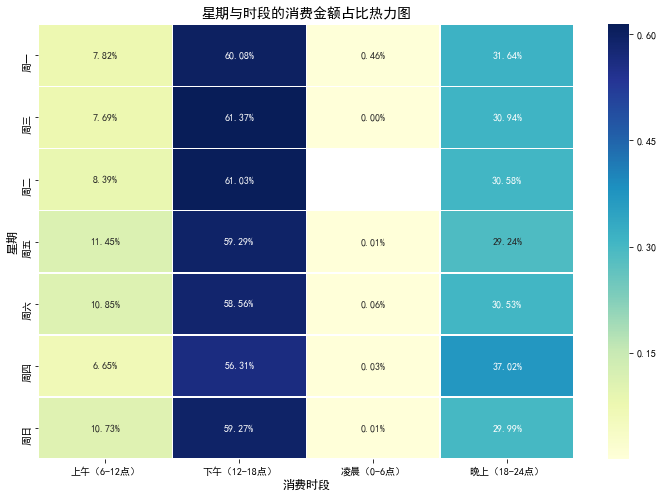

In [37]:
# 新增星期名称列
weekday_map = {0: '周一', 1: '周二', 2: '周三', 3: '周四', 
               4: '周五', 5: '周六', 6: '周日'}
member_sales['消费星期名称'] = member_sales['消费时间'].dt.weekday.map(weekday_map)

# 交叉表：星期 vs 时段 的消费金额占比
cross_table = pd.crosstab(
    member_sales['消费星期名称'],
    member_sales['消费时段'],
    values=member_sales['消费金额'],
    aggfunc='sum'
).apply(lambda x: x / x.sum(), axis=1)  # 标准化为占比

# 绘制热力图
plt.figure(figsize=(12, 8))
sns.heatmap(
    cross_table,
    annot=True,
    fmt=".2%",
    cmap="YlGnBu",
    linewidths=0.5,
    annot_kws={"fontsize": 10}
)
plt.title('星期与时段的消费金额占比热力图', fontsize=14)
plt.xlabel('消费时段', fontsize=12)
plt.ylabel('星期', fontsize=12)
plt.show()